# Análisis de parametros de calibración y mapas de desdistorsión

In [1]:
%load_ext autoreload
%autoreload 2

from src.rectification import save_rectified_images, show_rectified_pair
from src.calibration import *
import numpy as np

In [2]:
dataset = "stereo_budha_charuco"
calib, maps = load_calibration_data(dataset)

print("Claves disponibles en calib:", calib.keys())
print("Claves disponibles en maps:", maps.keys())

Claves disponibles en calib: dict_keys(['left_K', 'left_dist', 'right_K', 'right_dist', 'R', 'T', 'E', 'F', 'image_size'])
Claves disponibles en maps: dict_keys(['left_map_x', 'left_map_y', 'right_map_x', 'right_map_y', 'R1', 'R2', 'P1', 'P2', 'Q', 'validRoi1', 'validRoi2'])


## 1. Análisis de Parámetros de Calibración

En esta sección analizaremos los parámetros obtenidos durante el proceso de calibración estéreo y verificaremos que cumplan con las expectativas teóricas y las especificaciones de las cámaras utilizadas.


In [3]:
intrinsics_metrics = analyze_intrinsics(calib, verbose=True)

PARÁMETROS INTRÍNSECOS - CÁMARA IZQUIERDA

Distancia focal fx: 602.41 px
Distancia focal fy: 602.68 px
Relación fx/fy: 0.9996
Centro óptico (cx, cy): (952.03, 538.38)

PARÁMETROS INTRÍNSECOS - CÁMARA DERECHA

Distancia focal fx: 601.94 px
Distancia focal fy: 602.18 px
Relación fx/fy: 0.9996
Centro óptico (cx, cy): (953.00, 525.22)

COMPARACIÓN ENTRE CÁMARAS
Diferencia en fx: 0.48 px (0.08%)
Diferencia en fy: 0.50 px (0.08%)


### 1.1 Parámetros Intrínsecos de las Cámaras

Los parámetros intrínsecos definen las características ópticas de cada cámara:

**Matriz intrínsica K:**
$$
K = \begin{bmatrix} 
f_x & 0 & c_x \\ 
0 & f_y & c_y \\ 
0 & 0 & 1 
\end{bmatrix}
$$

donde:
- $(f_x, f_y)$: distancias focales en píxeles (eje x e y)
- $(c_x, c_y)$: coordenadas del punto principal (centro óptico)

**Verificaciones esperadas:**
1. $f_x \approx f_y$ (los píxeles deberían ser aproximadamente cuadrados)
2. $c_x \approx \text{ancho}/2$ y $c_y \approx \text{alto}/2$ (el centro óptico cerca del centro geométrico)
3. Los valores de $f$ deben ser consistentes con el FOV de la cámara


In [4]:
K1 = calib['left_K']  # Matriz intrínsica izquierda
K2 = calib['right_K']  # Matriz intrínsica derecha
D1 = calib['left_dist']  # Coeficientes de distorsión izquierda
D2 = calib['right_dist']  # Coeficientes de distorsión derecha

print("=" * 60)
print("PARÁMETROS INTRÍNSECOS - CÁMARA IZQUIERDA")
print("=" * 60)
print("\nMatriz K1:")
print(K1)
print(f"\nDistancia focal fx: {K1[0,0]:.2f} px")
print(f"Distancia focal fy: {K1[1,1]:.2f} px")
print(f"Relación fx/fy: {K1[0,0]/K1[1,1]:.4f} (debería estar cerca de 1.0)")
print(f"Centro óptico cx: {K1[0,2]:.2f} px")
print(f"Centro óptico cy: {K1[1,2]:.2f} px")

print("\n" + "=" * 60)
print("PARÁMETROS INTRÍNSECOS - CÁMARA DERECHA")
print("=" * 60)
print("\nMatriz K2:")
print(K2)
print(f"\nDistancia focal fx: {K2[0,0]:.2f} px")
print(f"Distancia focal fy: {K2[1,1]:.2f} px")
print(f"Relación fx/fy: {K2[0,0]/K2[1,1]:.4f} (debería estar cerca de 1.0)")
print(f"Centro óptico cx: {K2[0,2]:.2f} px")
print(f"Centro óptico cy: {K2[1,2]:.2f} px")

print("\n" + "=" * 60)
print("COMPARACIÓN ENTRE CÁMARAS")
print("=" * 60)
print(f"Diferencia en fx: {abs(K1[0,0] - K2[0,0]):.2f} px ({abs(K1[0,0] - K2[0,0])/K1[0,0]*100:.2f}%)")
print(f"Diferencia en fy: {abs(K1[1,1] - K2[1,1]):.2f} px ({abs(K1[1,1] - K2[1,1])/K1[1,1]*100:.2f}%)")

PARÁMETROS INTRÍNSECOS - CÁMARA IZQUIERDA

Matriz K1:
[[602.4122697    0.         952.03314806]
 [  0.         602.67666503 538.37793586]
 [  0.           0.           1.        ]]

Distancia focal fx: 602.41 px
Distancia focal fy: 602.68 px
Relación fx/fy: 0.9996 (debería estar cerca de 1.0)
Centro óptico cx: 952.03 px
Centro óptico cy: 538.38 px

PARÁMETROS INTRÍNSECOS - CÁMARA DERECHA

Matriz K2:
[[601.93653481   0.         953.00130936]
 [  0.         602.17619635 525.22354268]
 [  0.           0.           1.        ]]

Distancia focal fx: 601.94 px
Distancia focal fy: 602.18 px
Relación fx/fy: 0.9996 (debería estar cerca de 1.0)
Centro óptico cx: 953.00 px
Centro óptico cy: 525.22 px

COMPARACIÓN ENTRE CÁMARAS
Diferencia en fx: 0.48 px (0.08%)
Diferencia en fy: 0.50 px (0.08%)


In [5]:
img_width = 1280
img_height = 720

fov_h_left = 2 * np.arctan(img_width / (2 * K1[0, 0])) * 180 / np.pi
fov_v_left = 2 * np.arctan(img_height / (2 * K1[1, 1])) * 180 / np.pi

fov_h_right = 2 * np.arctan(img_width / (2 * K2[0, 0])) * 180 / np.pi
fov_v_right = 2 * np.arctan(img_height / (2 * K2[1, 1])) * 180 / np.pi

print("=" * 60)
print("CAMPO DE VISIÓN (FOV) CALCULADO")
print("=" * 60)
print(f"\nCámara Izquierda:")
print(f"  FOV horizontal: {fov_h_left:.1f}°")
print(f"  FOV vertical: {fov_v_left:.1f}°")
print(f"\nCámara Derecha:")
print(f"  FOV horizontal: {fov_h_right:.1f}°")
print(f"  FOV vertical: {fov_v_right:.1f}°")

CAMPO DE VISIÓN (FOV) CALCULADO

Cámara Izquierda:
  FOV horizontal: 93.5°
  FOV vertical: 61.7°

Cámara Derecha:
  FOV horizontal: 93.5°
  FOV vertical: 61.7°


### 1.2 Coeficientes de Distorsión

OpenCV utiliza el modelo de distorsión de Brown-Conrady=:

$$
D = [k_1, k_2, p_1, p_2, k_3]
$$

donde:
- $k_1, k_2, k_3$: coeficientes de distorsión radial
- $p_1, p_2$: coeficientes de distorsión tangencial

COEFICIENTES DE DISTORSIÓN

Cámara Izquierda (D1):
  k1 (radial): 0.012462
  k2 (radial): -0.029024
  p1 (tangencial): -0.001921
  p2 (tangencial): -0.000034
  k3 (radial): 0.004957

Cámara Derecha (D2):
  k1 (radial): 0.015109
  k2 (radial): -0.031595
  p1 (tangencial): -0.001783
  p2 (tangencial): 0.000873
  k3 (radial): 0.005541


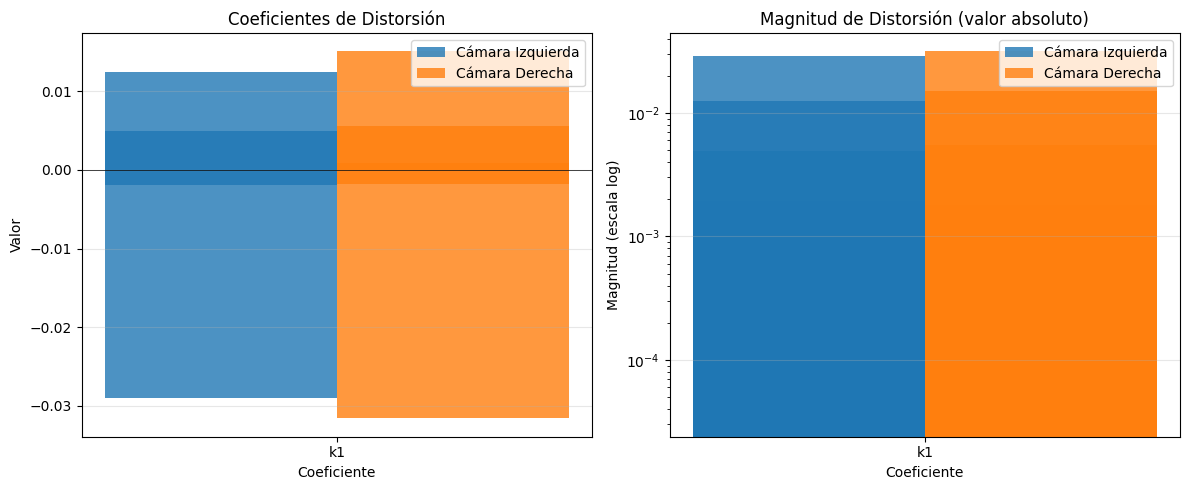

In [6]:
print("=" * 60)
print("COEFICIENTES DE DISTORSIÓN")
print("=" * 60)

print("\nCámara Izquierda (D1):")
print(f"  k1 (radial): {D1[0,0]:.6f}")
print(f"  k2 (radial): {D1[0,1]:.6f}")
print(f"  p1 (tangencial): {D1[0,2]:.6f}")
print(f"  p2 (tangencial): {D1[0,3]:.6f}")
print(f"  k3 (radial): {D1[0,4]:.6f}")

print("\nCámara Derecha (D2):")
print(f"  k1 (radial): {D2[0,0]:.6f}")
print(f"  k2 (radial): {D2[0,1]:.6f}")
print(f"  p1 (tangencial): {D2[0,2]:.6f}")
print(f"  p2 (tangencial): {D2[0,3]:.6f}")
print(f"  k3 (radial): {D2[0,4]:.6f}")

# Visualizar magnitud de distorsión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

coeffs_names = ['k1', 'k2', 'p1', 'p2', 'k3'][:len(D1)]
d1_values = D1.flatten()[:5]
d2_values = D2.flatten()[:5]

x = np.arange(len(coeffs_names))
width = 0.35

axes[0].bar(x - width/2, d1_values, width, label='Cámara Izquierda', alpha=0.8)
axes[0].bar(x + width/2, d2_values, width, label='Cámara Derecha', alpha=0.8)
axes[0].set_xlabel('Coeficiente')
axes[0].set_ylabel('Valor')
axes[0].set_title('Coeficientes de Distorsión')
axes[0].set_xticks(x)
axes[0].set_xticklabels(coeffs_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# Gráfico de magnitud absoluta (escala logarítmica)
axes[1].bar(x - width/2, np.abs(d1_values), width, label='Cámara Izquierda', alpha=0.8)
axes[1].bar(x + width/2, np.abs(d2_values), width, label='Cámara Derecha', alpha=0.8)
axes[1].set_xlabel('Coeficiente')
axes[1].set_ylabel('Magnitud (escala log)')
axes[1].set_title('Magnitud de Distorsión (valor absoluto)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(coeffs_names)
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 1.3 Parámetros Extrínsecos (Geometría Estéreo)

Los parámetros extrínsecos describen la relación geométrica entre las dos cámaras:

- **R (Rotación)**: matriz 3×3 que describe la rotación relativa entre cámaras
- **T (Traslación)**: vector 3×1 que describe la traslación relativa (baseline)

**Verificaciones esperadas:**
1. La baseline (norma de $T$) debe corresponder a la separación física entre cámaras
2. La matriz $R$ debería estar cerca de la identidad si las cámaras están bien alineadas
3. El determinante de $R$ debe ser +1 (rotación pura, sin reflexión)


In [7]:
R = calib['R']
T = calib['T']

print("=" * 60)
print("PARÁMETROS EXTRÍNSECOS")
print("=" * 60)

print("\nMatriz de Rotación R:")
print(R)
print(f"\nDeterminante de R: {np.linalg.det(R):.6f} (debe ser ≈ 1.0)")

from scipy.spatial.transform import Rotation as Rot
r = Rot.from_matrix(R)
euler_angles = r.as_euler('xyz', degrees=True)

print("\nÁngulos de Euler (xyz):")
print(f"  Roll (x):  {euler_angles[0]:.2f}°")
print(f"  Pitch (y): {euler_angles[1]:.2f}°")
print(f"  Yaw (z):   {euler_angles[2]:.2f}°")

print("\nVector de Traslación T (mm):")
print(T.flatten())

baseline_mm = np.linalg.norm(T)
baseline_m = baseline_mm / 1000.0

print("\nBaseline (distancia entre cámaras):")
print(f"  {baseline_mm:.2f} mm = {baseline_m:.4f} m")

print("\n" + "=" * 60)
print("VERIFICACIÓN")
print("=" * 60)

if np.allclose(R, np.eye(3), atol=0.1):
    print("✓ La matriz R está cerca de la identidad (buena alineación)")
else:
    print("⚠ La matriz R se desvía de la identidad (posible desalineación)")

max_angle = np.max(np.abs(euler_angles))
if max_angle < 5:
    print(f"✓ Ángulos de rotación pequeños (máx: {max_angle:.2f}°)")
elif max_angle < 15:
    print(f"⚠ Ángulos de rotación moderados (máx: {max_angle:.2f}°)")
else:
    print(f"⚠ Ángulos de rotación grandes (máx: {max_angle:.2f}°)")


PARÁMETROS EXTRÍNSECOS

Matriz de Rotación R:
[[ 9.99998642e-01  9.42980936e-04  1.35187748e-03]
 [-9.56731008e-04  9.99947452e-01  1.02067859e-02]
 [-1.34218163e-03 -1.02080654e-02  9.99946996e-01]]

Determinante de R: 1.000000 (debe ser ≈ 1.0)

Ángulos de Euler (xyz):
  Roll (x):  -0.58°
  Pitch (y): 0.08°
  Yaw (z):   -0.05°

Vector de Traslación T (mm):
[-59.98903064   0.21612993   0.30862235]

Baseline (distancia entre cámaras):
  59.99 mm = 0.0600 m

VERIFICACIÓN
✓ La matriz R está cerca de la identidad (buena alineación)
✓ Ángulos de rotación pequeños (máx: 0.58°)


### 1.4 Matrices de Proyección Rectificadas (P1, P2)

Después de la rectificación estéreo, se obtienen nuevas matrices de proyección:

$$
P_1 = \begin{bmatrix} 
f & 0 & c_x & 0 \\ 
0 & f & c_y & 0 \\ 
0 & 0 & 1 & 0 
\end{bmatrix}, \quad
P_2 = \begin{bmatrix} 
f & 0 & c_x & -f \cdot b \\ 
0 & f & c_y & 0 \\ 
0 & 0 & 1 & 0 
\end{bmatrix}
$$

donde $b$ es la baseline y el término $-f \cdot b$ en $P_2$ codifica la disparidad baseline.

**Verificaciones esperadas:**
1. Misma distancia focal $f$ para ambas cámaras
2. Mismo centro óptico $(c_x, c_y)$ (líneas epipolares horizontales)
3. El elemento $P_2[0,3]$ debe ser $\approx -f \cdot \text{baseline}$


In [8]:
P1 = maps.get('P1', calib.get('P1'))
P2 = maps.get('P2', calib.get('P2'))

print("=" * 60)
print("MATRICES DE PROYECCIÓN RECTIFICADAS")
print("=" * 60)

print("\nMatriz P1 (cámara izquierda):")
print(P1)

print("\nMatriz P2 (cámara derecha):")
print(P2)

f_rect = P1[0, 0]
cx_rect = P1[0, 2]
cy_rect = P1[1, 2]

print("\n" + "=" * 60)
print("PARÁMETROS RECTIFICADOS")
print("=" * 60)
print(f"\nDistancia focal rectificada (f): {f_rect:.2f} px")
print(f"Centro óptico (cx, cy): ({cx_rect:.2f}, {cy_rect:.2f})")

f2_rect = P2[0, 0]
cx2_rect = P2[0, 2]
cy2_rect = P2[1, 2]

print(f"\nVerificación de alineación:")
print(f"  Diferencia en f: {abs(f_rect - f2_rect):.6f} px")
print(f"  Diferencia en cx: {abs(cx_rect - cx2_rect):.6f} px")
print(f"  Diferencia en cy: {abs(cy_rect - cy2_rect):.6f} px")

if abs(cy_rect - cy2_rect) < 0.1:
    print("  ✓ Líneas epipolares correctamente alineadas horizontalmente")
else:
    print("  ⚠ Posible desalineación en líneas epipolares")

Tx = P2[0, 3]
baseline_from_P2 = -Tx / f_rect
baseline_from_T = np.linalg.norm(T)

print(f"\nBaseline verificado desde P2: {baseline_from_P2:.6f} mm")
print(f"Baseline desde T: {baseline_from_T:.6f} mm")
print(f"Diferencia: {abs(baseline_from_P2 - baseline_from_T):.6f} mm")

if abs(baseline_from_P2 - baseline_from_T) / baseline_from_T < 0.01:
    print("✓ Baseline consistente entre P2 y T")
else:
    print("⚠ Discrepancia en baseline")


MATRICES DE PROYECCIÓN RECTIFICADAS

Matriz P1 (cámara izquierda):
[[604.28439922   0.         966.26376343   0.        ]
 [  0.         604.28439922 524.75611877   0.        ]
 [  0.           0.           1.           0.        ]]

Matriz P2 (cámara derecha):
[[ 6.04284399e+02  0.00000000e+00  9.66263763e+02 -3.62511503e+04]
 [ 0.00000000e+00  6.04284399e+02  5.24756119e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]

PARÁMETROS RECTIFICADOS

Distancia focal rectificada (f): 604.28 px
Centro óptico (cx, cy): (966.26, 524.76)

Verificación de alineación:
  Diferencia en f: 0.000000 px
  Diferencia en cx: 0.000000 px
  Diferencia en cy: 0.000000 px
  ✓ Líneas epipolares correctamente alineadas horizontalmente

Baseline verificado desde P2: 59.990214 mm
Baseline desde T: 59.990214 mm
Diferencia: 0.000000 mm
✓ Baseline consistente entre P2 y T


### 1.5 Análisis de Mapas de Rectificación

Los mapas de rectificación (`left_map_x`, `left_map_y`, `right_map_x`, `right_map_y`) son transformaciones que corrigen:
1. **Distorsión de lente** (mediante los coeficientes $D_1$ y $D_2$)
2. **Alineación epipolar** (mediante las matrices de rotación $R_1$ y $R_2$)

**Verificaciones esperadas:**
- Los mapas deben contener valores válidos (no NaN o infinitos)
- El rango de desplazamiento debería ser mayor en los bordes (donde la distorsión es más fuerte)
- Las ROIs válidas indican las regiones sin información perdida tras la rectificación

**Matriz Q de reproyección:**

La matriz $Q$ permite convertir disparidad en coordenadas 3D:

$$
\begin{bmatrix} X \\ Y \\ Z \\ W \end{bmatrix} = Q \cdot \begin{bmatrix} x \\ y \\ d \\ 1 \end{bmatrix}
$$

donde $d$ es la disparidad y las coordenadas 3D se obtienen como $(X/W, Y/W, Z/W)$.


In [9]:
left_map_x = maps['left_map_x']
left_map_y = maps['left_map_y']
right_map_x = maps['right_map_x']
right_map_y = maps['right_map_y']

print("=" * 60)
print("ANÁLISIS DE MAPAS DE RECTIFICACIÓN")
print("=" * 60)

print(f"\nDimensiones de los mapas: {left_map_x.shape}")
print(f"Tipo de datos: {left_map_x.dtype}")

h, w = left_map_x.shape
y_grid, x_grid = np.mgrid[0:h, 0:w].astype(np.float32)

disp_left_x = left_map_x - x_grid
disp_left_y = left_map_y - y_grid
disp_left_mag = np.sqrt(disp_left_x**2 + disp_left_y**2)

disp_right_x = right_map_x - x_grid
disp_right_y = right_map_y - y_grid
disp_right_mag = np.sqrt(disp_right_x**2 + disp_right_y**2)

print("\n" + "=" * 60)
print("ESTADÍSTICAS DE DESPLAZAMIENTO - CÁMARA IZQUIERDA")
print("=" * 60)
print(f"Desplazamiento en X: [{disp_left_x.min():.2f}, {disp_left_x.max():.2f}] px")
print(f"Desplazamiento en Y: [{disp_left_y.min():.2f}, {disp_left_y.max():.2f}] px")
print(f"Magnitud promedio: {disp_left_mag.mean():.2f} px")
print(f"Magnitud máxima: {disp_left_mag.max():.2f} px")

print("\n" + "=" * 60)
print("ESTADÍSTICAS DE DESPLAZAMIENTO - CÁMARA DERECHA")
print("=" * 60)
print(f"Desplazamiento en X: [{disp_right_x.min():.2f}, {disp_right_x.max():.2f}] px")
print(f"Desplazamiento en Y: [{disp_right_y.min():.2f}, {disp_right_y.max():.2f}] px")
print(f"Magnitud promedio: {disp_right_mag.mean():.2f} px")
print(f"Magnitud máxima: {disp_right_mag.max():.2f} px")

roi1 = maps.get('validRoi1', None)
roi2 = maps.get('validRoi2', None)

if roi1 is not None and roi2 is not None:
    x1, y1, w1, h1 = roi1
    x2, y2, w2, h2 = roi2
    
    print("\n" + "=" * 60)
    print("REGIONES DE INTERÉS VÁLIDAS (ROI)")
    print("=" * 60)
    print(f"ROI Izquierda: x={x1}, y={y1}, w={w1}, h={h1}")
    print(f"  Área válida: {w1 * h1} px ({w1*h1/(w*h)*100:.1f}% de la imagen)")
    print(f"\nROI Derecha: x={x2}, y={y2}, w={w2}, h={h2}")
    print(f"  Área válida: {w2 * h2} px ({w2*h2/(w*h)*100:.1f}% de la imagen)")
    
    x = max(x1, x2)
    y = max(y1, y2)
    xe = min(x1 + w1, x2 + w2)
    ye = min(y1 + h1, y2 + h2)
    w_inter = xe - x
    h_inter = ye - y
    
    print(f"\nROI Intersección: w={w_inter}, h={h_inter}")
    print(f"  Área común: {w_inter * h_inter} px ({w_inter*h_inter/(w*h)*100:.1f}% de la imagen)")

Q = maps['Q']
print("\n" + "=" * 60)
print("MATRIZ DE REPROYECCIÓN Q")
print("=" * 60)
print(Q)
print(f"\nElemento Q[2,3] (relacionado con baseline y focal): {Q[2,3]:.6f}")
print("  Este valor determina la escala de profundidad: Z = f*baseline/disparidad")


ANÁLISIS DE MAPAS DE RECTIFICACIÓN

Dimensiones de los mapas: (1080, 1920)
Tipo de datos: float32

ESTADÍSTICAS DE DESPLAZAMIENTO - CÁMARA IZQUIERDA
Desplazamiento en X: [-108.68, 97.88] px
Desplazamiento en Y: [-52.93, 60.33] px
Magnitud promedio: 27.49 px
Magnitud máxima: 120.44 px

ESTADÍSTICAS DE DESPLAZAMIENTO - CÁMARA DERECHA
Desplazamiento en X: [-95.24, 97.93] px
Desplazamiento en Y: [-57.25, 59.50] px
Magnitud promedio: 24.58 px
Magnitud máxima: 113.44 px

REGIONES DE INTERÉS VÁLIDAS (ROI)
ROI Izquierda: x=0, y=0, w=1920, h=1079
  Área válida: 2071680 px (99.9% de la imagen)

ROI Derecha: x=0, y=0, w=1920, h=1080
  Área válida: 2073600 px (100.0% de la imagen)

ROI Intersección: w=1920, h=1079
  Área común: 2071680 px (99.9% de la imagen)

MATRIZ DE REPROYECCIÓN Q
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -9.66263763e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -5.24756119e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  6.04284399e+02]
 [ 0.00000000e+

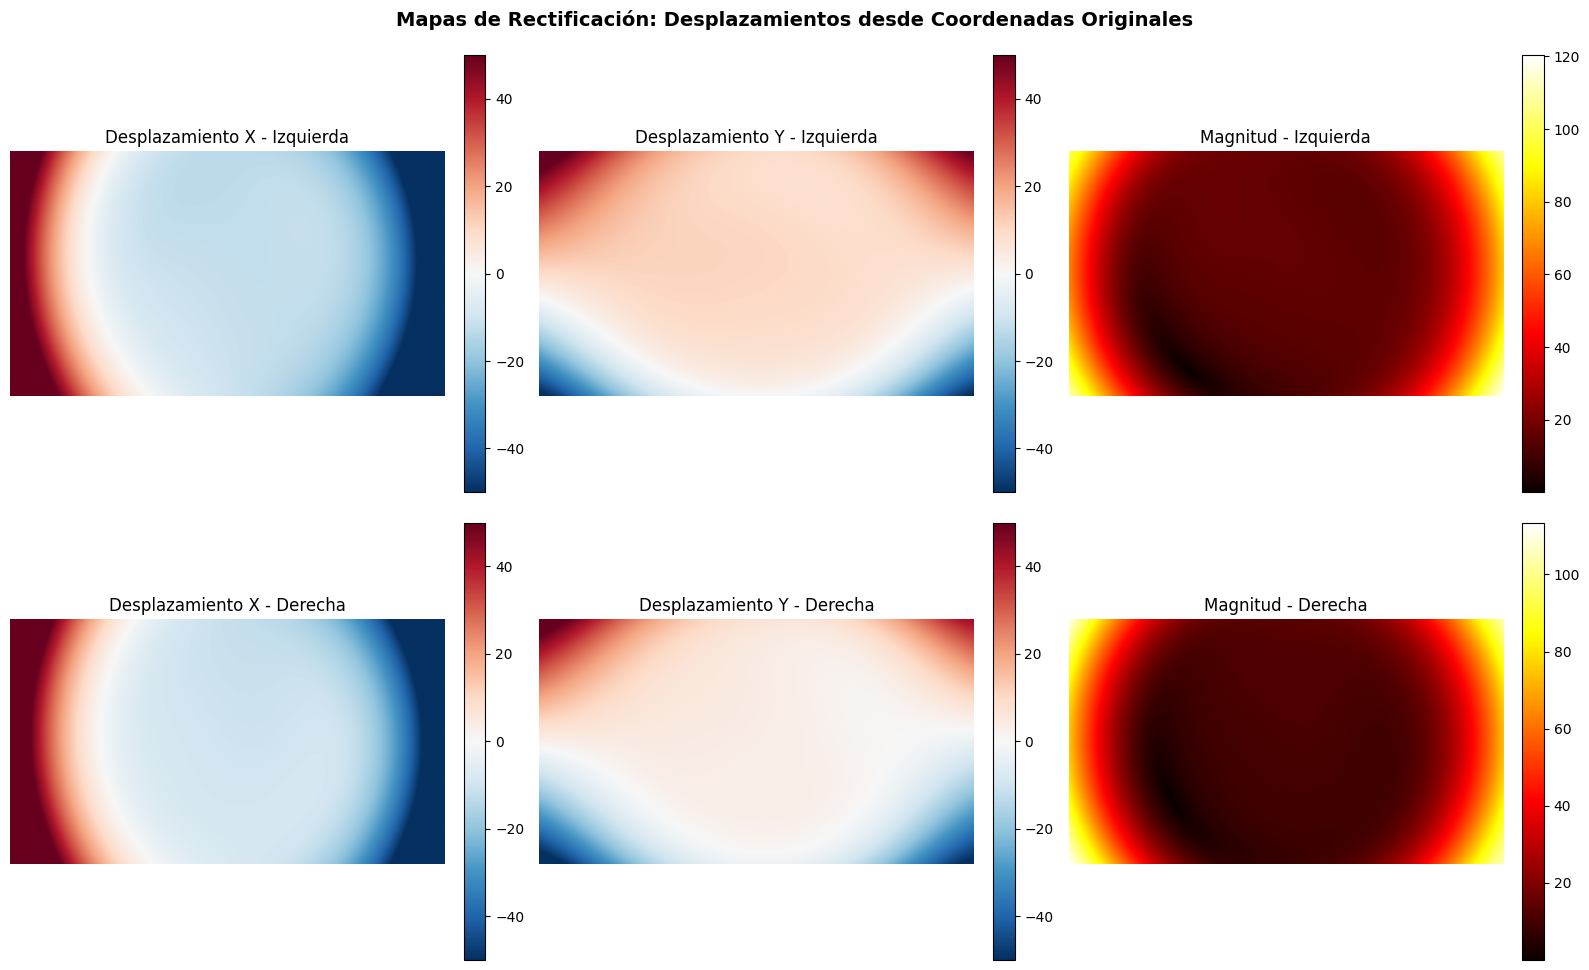


Interpretación:
- Desplazamiento X (azul = izquierda, rojo = derecha)
- Desplazamiento Y (azul = arriba, rojo = abajo)
- Magnitud (amarillo/blanco = mayor desplazamiento)
- Los desplazamientos mayores en los bordes indican corrección de distorsión radial


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

im0 = axes[0, 0].imshow(disp_left_x, cmap='RdBu_r', vmin=-50, vmax=50)
axes[0, 0].set_title('Desplazamiento X - Izquierda')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[1, 0].imshow(disp_right_x, cmap='RdBu_r', vmin=-50, vmax=50)
axes[1, 0].set_title('Desplazamiento X - Derecha')
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[0, 1].imshow(disp_left_y, cmap='RdBu_r', vmin=-50, vmax=50)
axes[0, 1].set_title('Desplazamiento Y - Izquierda')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(disp_right_y, cmap='RdBu_r', vmin=-50, vmax=50)
axes[1, 1].set_title('Desplazamiento Y - Derecha')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

im4 = axes[0, 2].imshow(disp_left_mag, cmap='hot')
axes[0, 2].set_title('Magnitud - Izquierda')
axes[0, 2].axis('off')
plt.colorbar(im4, ax=axes[0, 2], fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(disp_right_mag, cmap='hot')
axes[1, 2].set_title('Magnitud - Derecha')
axes[1, 2].axis('off')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle('Mapas de Rectificación: Desplazamientos desde Coordenadas Originales', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Desplazamiento X (azul = izquierda, rojo = derecha)")
print("- Desplazamiento Y (azul = arriba, rojo = abajo)")
print("- Magnitud (amarillo/blanco = mayor desplazamiento)")
print("- Los desplazamientos mayores en los bordes indican corrección de distorsión radial")


### 1.6 Resumen de Calibración para Todos los Datasets

A continuación se presenta un análisis resumido de los parámetros de calibración para todos los datasets disponibles.


In [11]:
datasets = [
    "stereo_budha_charuco",
    "stereo_budha_board", 
    "stereo_warren",
    "stereo_tambor"
]

for dataset_name in datasets:
    try:
        print_compact_summary(dataset_name)
    except Exception as e:
        print(f"\n{'='*70}")
        print(f"DATASET: {dataset_name}")
        print(f"{'='*70}")
        print(f"⚠ Error al cargar: {e}")



DATASET: stereo_budha_charuco

📷 Intrínsecos:
   Focal L: fx=602.4, fy=602.7 | R: fx=601.9, fy=602.2
   Diferencia focal: 0.08%
   FOV: 115.8° × 83.7°

🔍 Distorsión:
   k1: L=0.0125, R=0.0151
   k2: L=-0.0290, R=-0.0316

📐 Extrínsecos:
   Baseline: 59.99 mm (6.00 cm)
   Rotación máx: 0.58°

✅ Rectificación:
   Alineación epipolar (Δcy): 0.0000 px
   Estado: ✓ Excelente
   ROI válida: 99.9% de la imagen

DATASET: stereo_budha_board

DATASET: stereo_budha_board
⚠ Error al cargar: [Errno 2] No such file or directory: 'datasets/stereo_budha_board/data/stereo_calibration.pkl'

DATASET: stereo_warren

DATASET: stereo_warren
⚠ Error al cargar: [Errno 2] No such file or directory: 'datasets/stereo_warren/data/stereo_calibration.pkl'

DATASET: stereo_tambor

📷 Intrínsecos:
   Focal L: fx=315.9, fy=316.3 | R: fx=314.3, fy=314.7
   Diferencia focal: 0.51%
   FOV: 103.4° × 87.0°

🔍 Distorsión:
   k1: L=-0.0081, R=-0.0007
   k2: L=-0.0067, R=-0.0148

📐 Extrínsecos:
   Baseline: 59.83 mm (5.98 cm)


#### Comparación Entre Datasets

Ahora generamos una tabla comparativa con las métricas clave:


In [12]:
import pandas as pd

comparison_data = []

for dataset_name in datasets:
    try:
        calib, maps = load_calibration_data(dataset_name)
        
        K1 = calib['left_K']
        K2 = calib['right_K']
        D1 = calib['left_dist']
        D2 = calib['right_dist']
        T = calib['T']
        R = calib['R']
        P1 = maps['P1']
        P2 = maps['P2']
        
        baseline = np.linalg.norm(T)
        
        # Calcular FOV
        img_size = calib.get('image_size', (1280, 720))
        fov_h, fov_v = calculate_fov(K1, img_size[0], img_size[1])
        
        # Ángulos de Euler
        r = Rot.from_matrix(R)
        euler = r.as_euler('xyz', degrees=True)
        max_angle = np.max(np.abs(euler))
        
        # Alineación epipolar
        cy_diff = abs(P1[1,2] - P2[1,2])
        
        comparison_data.append({
            'Dataset': dataset_name.replace('stereo_', ''),
            'Focal (px)': f"{K1[0,0]:.1f}",
            'FOV H (°)': f"{fov_h:.1f}",
            'FOV V (°)': f"{fov_v:.1f}",
            'Baseline (mm)': f"{baseline:.1f}",
            'k1 distorsión': f"{D1[0,0]:.4f}",
            'Rot. máx (°)': f"{max_angle:.2f}",
            'Alin. Epipolar (px)': f"{cy_diff:.4f}",
            'Estado': '✓' if cy_diff < 0.1 else '⚠'
        })
    except Exception as e:
        comparison_data.append({
            'Dataset': dataset_name.replace('stereo_', ''),
            'Focal (px)': 'N/A',
            'FOV H (°)': 'N/A',
            'FOV V (°)': 'N/A',
            'Baseline (mm)': 'N/A',
            'k1 distorsión': 'N/A',
            'Rot. máx (°)': 'N/A',
            'Alin. Epipolar (px)': 'N/A',
            'Estado': '✗'
        })

df = pd.DataFrame(comparison_data)
print("\n" + "=" * 120)
print("TABLA COMPARATIVA DE CALIBRACIONES")
print("=" * 120)
print(df.to_string(index=False))
print("\n" + "=" * 120)



TABLA COMPARATIVA DE CALIBRACIONES
      Dataset Focal (px) FOV H (°) FOV V (°) Baseline (mm) k1 distorsión Rot. máx (°) Alin. Epipolar (px) Estado
budha_charuco      602.4     115.8      83.7          60.0        0.0125         0.58              0.0000      ✓
  budha_board        N/A       N/A       N/A           N/A           N/A          N/A                 N/A      ✗
       warren        N/A       N/A       N/A           N/A           N/A          N/A                 N/A      ✗
       tambor      315.9     103.4      87.0          59.8       -0.0081         0.14              0.0000      ✓



#### Visualización Comparativa

Generamos gráficos comparativos de las métricas principales:


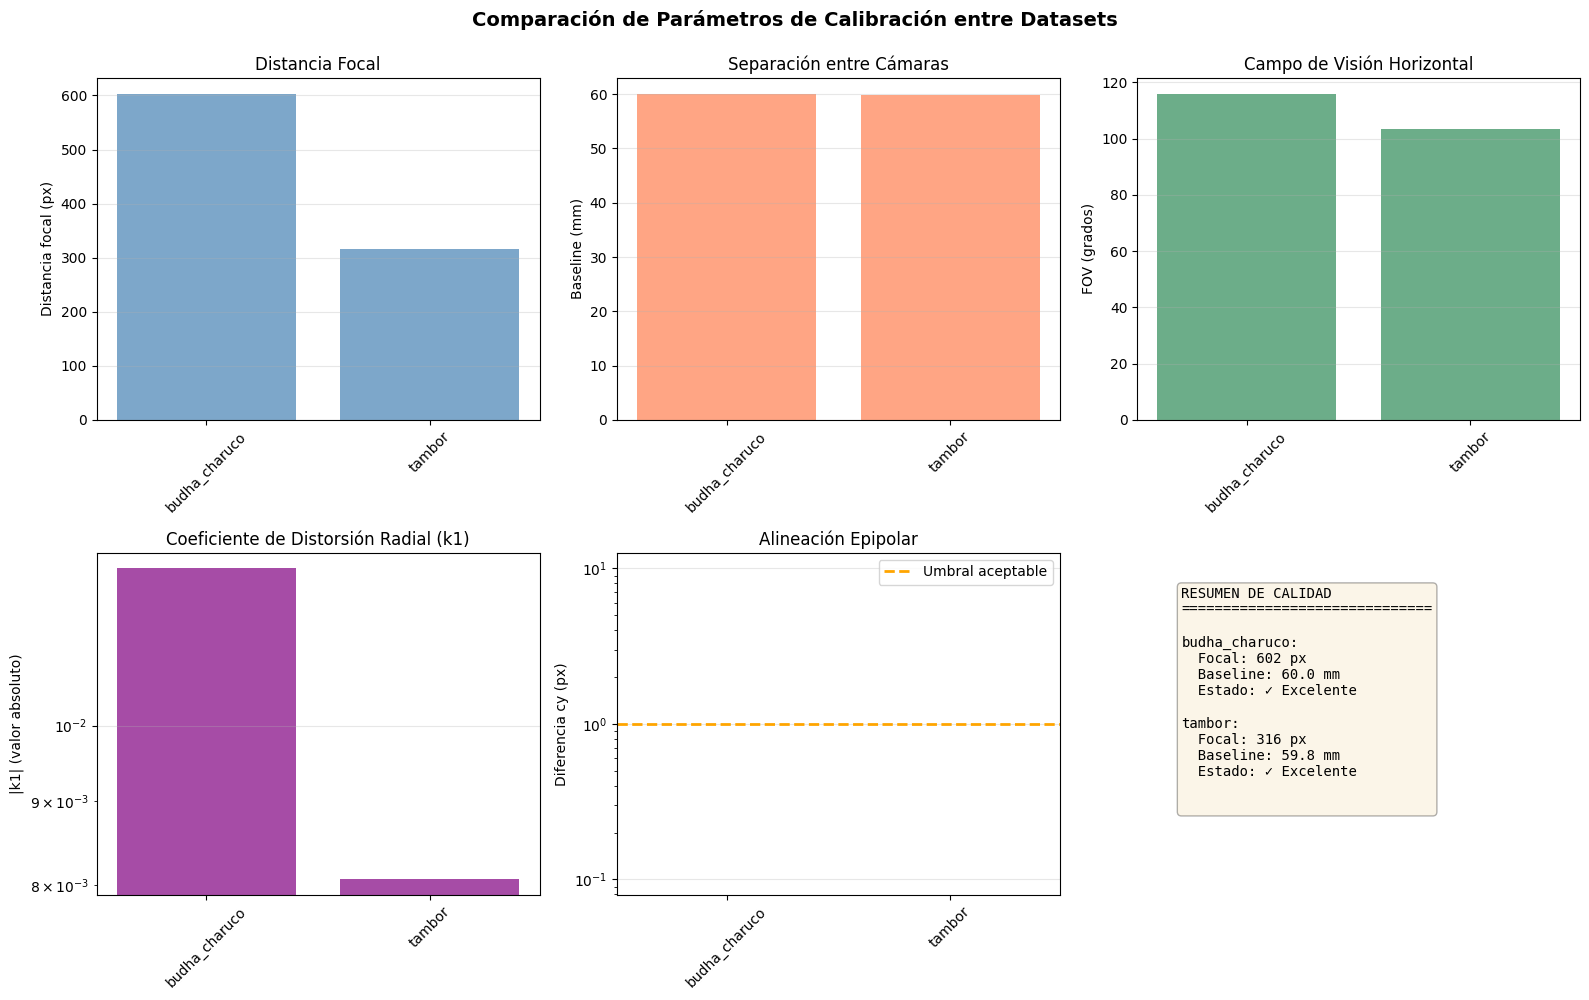

In [13]:
import matplotlib.pyplot as plt
import numpy as np

dataset_names = []
focal_lengths = []
baselines = []
fov_horizontal = []
distortion_k1 = []
epipolar_alignment = []

for dataset_name in datasets:
    try:
        calib, maps = load_calibration_data(dataset_name)
        
        K1 = calib['left_K']
        D1 = calib['left_dist']
        T = calib['T']
        P1 = maps['P1']
        P2 = maps['P2']
        
        img_size = calib.get('image_size', (1280, 720))
        fov_h, _ = calculate_fov(K1, img_size[0], img_size[1])
        
        dataset_names.append(dataset_name.replace('stereo_', ''))
        focal_lengths.append(K1[0,0])
        baselines.append(np.linalg.norm(T))
        fov_horizontal.append(fov_h)
        distortion_k1.append(abs(D1[0,0]))
        epipolar_alignment.append(abs(P1[1,2] - P2[1,2]))
    except:
        pass

# Crear subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distancia focal
axes[0, 0].bar(dataset_names, focal_lengths, color='steelblue', alpha=0.7)
axes[0, 0].set_ylabel('Distancia focal (px)')
axes[0, 0].set_title('Distancia Focal')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Baseline
axes[0, 1].bar(dataset_names, baselines, color='coral', alpha=0.7)
axes[0, 1].set_ylabel('Baseline (mm)')
axes[0, 1].set_title('Separación entre Cámaras')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. FOV
axes[0, 2].bar(dataset_names, fov_horizontal, color='seagreen', alpha=0.7)
axes[0, 2].set_ylabel('FOV (grados)')
axes[0, 2].set_title('Campo de Visión Horizontal')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Distorsión k1 (valor absoluto, escala log)
axes[1, 0].bar(dataset_names, distortion_k1, color='purple', alpha=0.7)
axes[1, 0].set_ylabel('|k1| (valor absoluto)')
axes[1, 0].set_title('Coeficiente de Distorsión Radial (k1)')
axes[1, 0].set_yscale('log')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Alineación epipolar
axes[1, 1].bar(dataset_names, epipolar_alignment, color='darkred', alpha=0.7)
axes[1, 1].set_ylabel('Diferencia cy (px)')
axes[1, 1].set_title('Alineación Epipolar')
axes[1, 1].axhline(y=1.0, color='orange', linestyle='--', linewidth=2, label='Umbral aceptable')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_yscale('log')

# 6. Resumen de calidad
axes[1, 2].axis('off')
quality_text = "RESUMEN DE CALIDAD\n" + "="*30 + "\n\n"

for i, name in enumerate(dataset_names):
    quality = "✓ Excelente" if epipolar_alignment[i] < 0.1 else ("⚠ Bueno" if epipolar_alignment[i] < 1.0 else "⚠ Revisar")
    quality_text += f"{name}:\n"
    quality_text += f"  Focal: {focal_lengths[i]:.0f} px\n"
    quality_text += f"  Baseline: {baselines[i]:.1f} mm\n"
    quality_text += f"  Estado: {quality}\n\n"

axes[1, 2].text(0.1, 0.9, quality_text, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Comparación de Parámetros de Calibración entre Datasets', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


#### Conclusiones del Análisis de Calibración

**Interpretación de resultados:**

1. **Distancia Focal:** Valores similares indican que se usó el mismo tipo de cámara/lente. Variaciones significativas pueden indicar diferentes cámaras o configuraciones de zoom.

2. **Baseline:** La separación entre cámaras afecta directamente la precisión de profundidad:
   - Mayor baseline → mejor resolución en profundidad para objetos lejanos
   - Menor baseline → mejor para objetos cercanos, menor oclusión

3. **Campo de Visión (FOV):** Determina el área visible. FOV más amplio cubre más escena pero puede tener mayor distorsión en los bordes.

4. **Distorsión k1:** Valores más altos (en magnitud) indican mayor distorsión de barril (k1 < 0) o cojín (k1 > 0). Lentes gran angular típicamente tienen distorsión de barril.

5. **Alineación Epipolar:** Mide qué tan bien están alineadas las líneas epipolares después de la rectificación:
   - < 0.1 px: Excelente (mínimo error de búsqueda en correspondencia)
   - < 1.0 px: Bueno (error aceptable)
   - ≥ 1.0 px: Revisar calibración o proceso de rectificación


---

## 2. Rectificación de Imágenes Estéreo

Esta sección aplica la rectificación estéreo a los pares de imágenes capturadas, utilizando los parámetros de calibración previamente calculados.

### Proceso
1. Carga de parámetros de calibración y mapas de rectificación
2. Aplicación de remapeo a todas las imágenes
3. Recorte según ROI válida
4. Exportación de imágenes rectificadas y parámetros en formato JSON


# Rectificación de Imágenes Estéreo

Este notebook aplica la rectificación estéreo a los pares de imágenes capturadas, utilizando los parámetros de calibración previamente calculados.

## Proceso
1. Carga de parámetros de calibración y mapas de rectificación
2. Aplicación de remapeo a todas las imágenes
3. Recorte según ROI válida
4. Exportación de imágenes rectificadas y parámetros en formato JSON


## Dataset: Budha Charuco

In [14]:
save_rectified_images("stereo_budha_charuco")

['datasets/stereo_budha_charuco/data/captures/left_0.jpg', 'datasets/stereo_budha_charuco/data/captures/left_1.jpg', 'datasets/stereo_budha_charuco/data/captures/left_2.jpg', 'datasets/stereo_budha_charuco/data/captures/left_3.jpg', 'datasets/stereo_budha_charuco/data/captures/left_4.jpg', 'datasets/stereo_budha_charuco/data/captures/left_5.jpg', 'datasets/stereo_budha_charuco/data/captures/left_6.jpg', 'datasets/stereo_budha_charuco/data/captures/left_7.jpg', 'datasets/stereo_budha_charuco/data/captures/left_8.jpg', 'datasets/stereo_budha_charuco/data/captures/left_9.jpg', 'datasets/stereo_budha_charuco/data/captures/left_10.jpg', 'datasets/stereo_budha_charuco/data/captures/left_11.jpg', 'datasets/stereo_budha_charuco/data/captures/left_12.jpg', 'datasets/stereo_budha_charuco/data/captures/left_13.jpg', 'datasets/stereo_budha_charuco/data/captures/left_14.jpg', 'datasets/stereo_budha_charuco/data/captures/left_15.jpg', 'datasets/stereo_budha_charuco/data/captures/left_16.jpg', 'datas

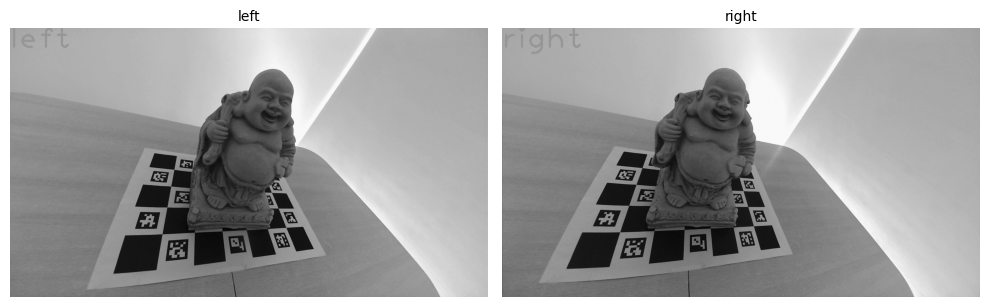

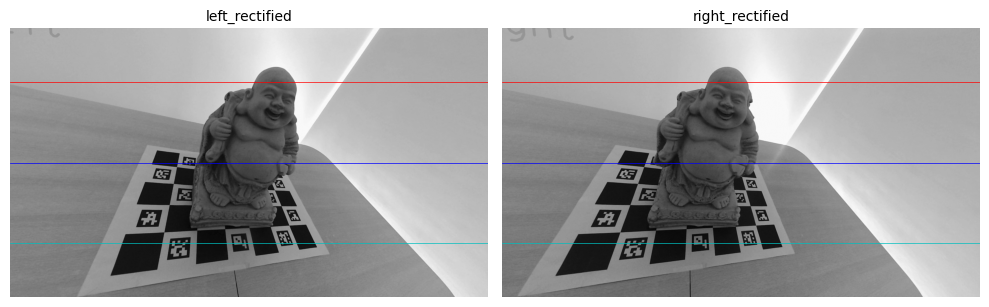

In [15]:
show_rectified_pair("stereo_budha_charuco", 0)

## Dataset: Tambor


In [16]:
save_rectified_images("stereo_tambor")

['datasets/stereo_tambor/data/captures/left_0.jpg', 'datasets/stereo_tambor/data/captures/left_1.jpg', 'datasets/stereo_tambor/data/captures/left_2.jpg', 'datasets/stereo_tambor/data/captures/left_3.jpg', 'datasets/stereo_tambor/data/captures/left_4.jpg', 'datasets/stereo_tambor/data/captures/left_5.jpg', 'datasets/stereo_tambor/data/captures/left_6.jpg', 'datasets/stereo_tambor/data/captures/left_7.jpg', 'datasets/stereo_tambor/data/captures/left_8.jpg', 'datasets/stereo_tambor/data/captures/left_9.jpg', 'datasets/stereo_tambor/data/captures/left_10.jpg', 'datasets/stereo_tambor/data/captures/left_11.jpg', 'datasets/stereo_tambor/data/captures/left_12.jpg', 'datasets/stereo_tambor/data/captures/left_13.jpg', 'datasets/stereo_tambor/data/captures/left_14.jpg', 'datasets/stereo_tambor/data/captures/left_15.jpg', 'datasets/stereo_tambor/data/captures/left_16.jpg'] ['datasets/stereo_tambor/data/captures/right_0.jpg', 'datasets/stereo_tambor/data/captures/right_1.jpg', 'datasets/stereo_tam

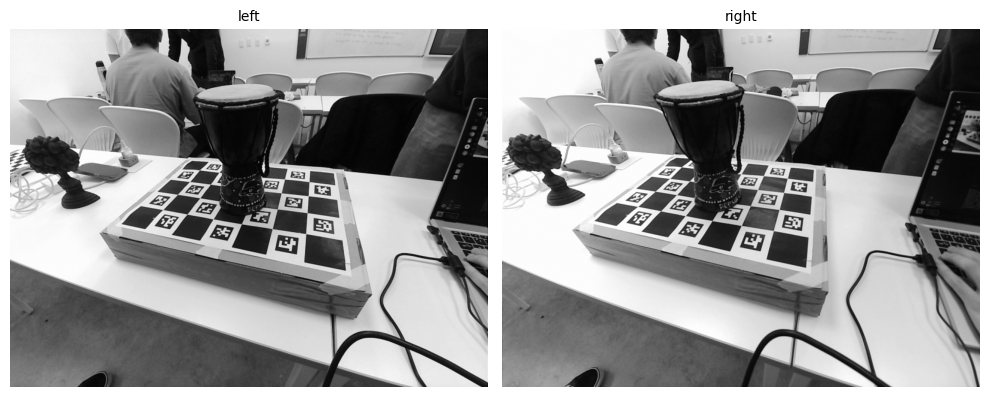

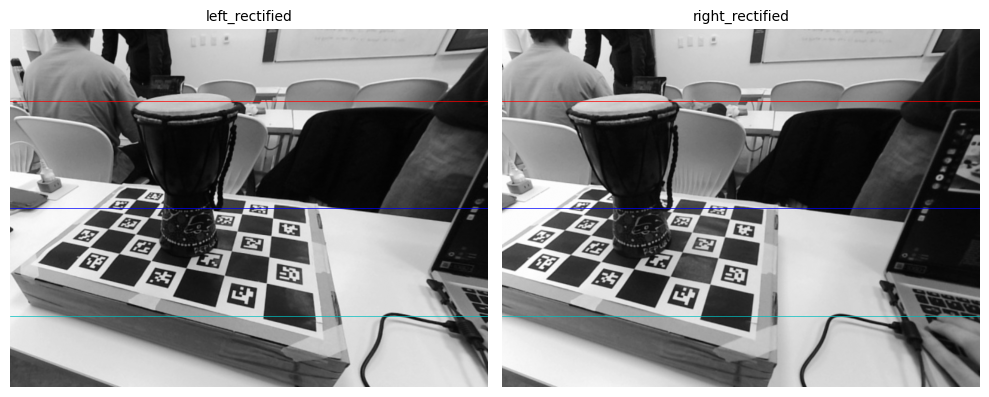

In [17]:
show_rectified_pair("stereo_tambor", 0)